In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

In [53]:
CrimePerYear = pd.read_csv('CrimePerYear.csv')
CrimeByMonth = pd.read_csv('CrimeByMonth.csv')
CrimeByHour = pd.read_csv('CrimeByHour.csv')
CrimeByDistrict = pd.read_csv('CrimeByDistrict.csv')
CrimeByLocation = pd.read_csv('CrimesByLocation.csv')
    

In [54]:
print(CrimePerYear.head())
print(CrimeByMonth.shape)

   Crime_Year                PrimaryType  Total_Crime  Total_Arrest
0        2001                      Arson         1011           181
1        2001                    Assault        31389          7152
2        2001                    Battery        93472         20467
3        2001                   Burglary        26015          1695
4        2001  Concealed Carry Violation            1             1
(304, 3)


In [55]:
yearly = CrimePerYear.groupby('Crime_Year')['Total_Crime'].sum().reset_index()

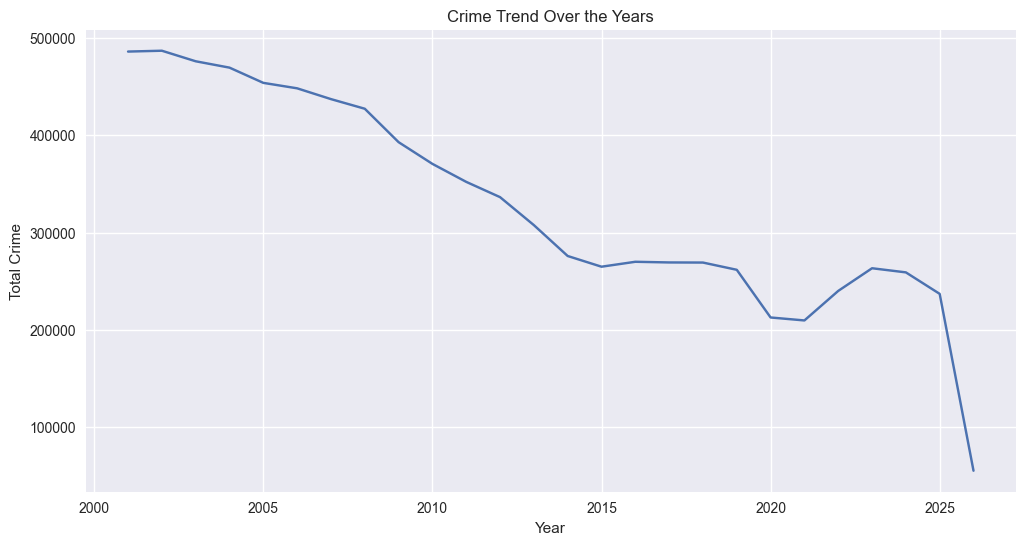

In [56]:
plt.figure(figsize=(12, 6))
plt.plot(yearly['Crime_Year'], yearly['Total_Crime'])
plt.xlabel('Year')
plt.ylabel('Total Crime')
plt.title('Crime Trend Over the Years')
plt.savefig('crime_trend.png', dpi=300, bbox_inches='tight')
plt.show()

The City of Chicago crime rate had it peak in 2001-2003. And the start of 2004 started to go down and the start of covid drastically went down.

In [57]:
Top10 = CrimePerYear.groupby('PrimaryType')['Total_Crime'].sum().reset_index().sort_values(by='Total_Crime', ascending=False).head(10)

C:\Users\marca\AppData\Local\Temp\ipykernel_22108\3263798657.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Crime', y='PrimaryType', data=Top10, palette='viridis')


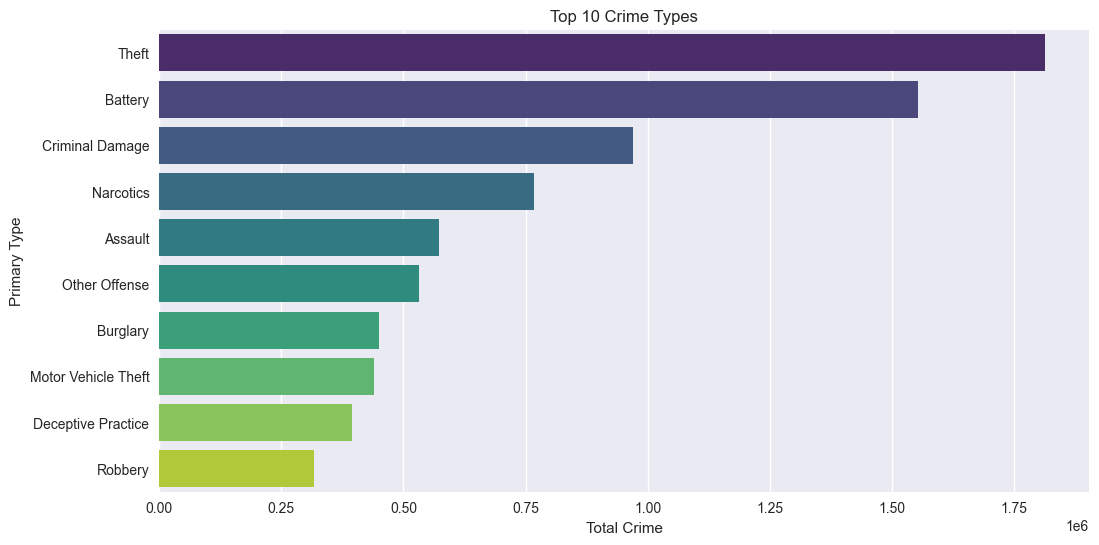

In [58]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Total_Crime', y='PrimaryType', data=Top10, palette='viridis')
plt.xlabel('Total Crime')
plt.ylabel('Primary Type')
plt.title('Top 10 Crime Types')
plt.savefig('top10_crimes.png', dpi=300, bbox_inches='tight')
plt.show()


The most commited crime is theft

In [59]:
ArrestRate = CrimePerYear.groupby('PrimaryType')[['Total_Arrest', 'Total_Crime']].sum().reset_index()

ArrestRate['Arrest_Rate'] = ArrestRate['Total_Arrest'] / ArrestRate['Total_Crime'] * 100

print(ArrestRate.sort_values(by='Arrest_Rate', ascending=False).head(10))



                  PrimaryType  Total_Arrest  Total_Crime  Arrest_Rate
9           Domestic Violence             1            1   100.000000
24               Prostitution         70170        70488    99.548859
18                  Narcotics        761703       766905    99.321689
10                   Gambling         14559        14666    99.270421
16       Liquor Law Violation         15319        15474    98.998320
25           Public Indecency           224          228    98.245614
4   Concealed Carry Violation          1687         1742    96.842710
13  Interference With Officer         18935        20661    91.646097
20                  Obscenity           715          977    73.183214
32          Weapons Violation         92260       126940    72.680006


C:\Users\marca\AppData\Local\Temp\ipykernel_22108\3884290704.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Arrest_Rate', y='PrimaryType', data=ArrestRate.sort_values(by='Arrest_Rate', ascending=False).head(10), palette='viridis')


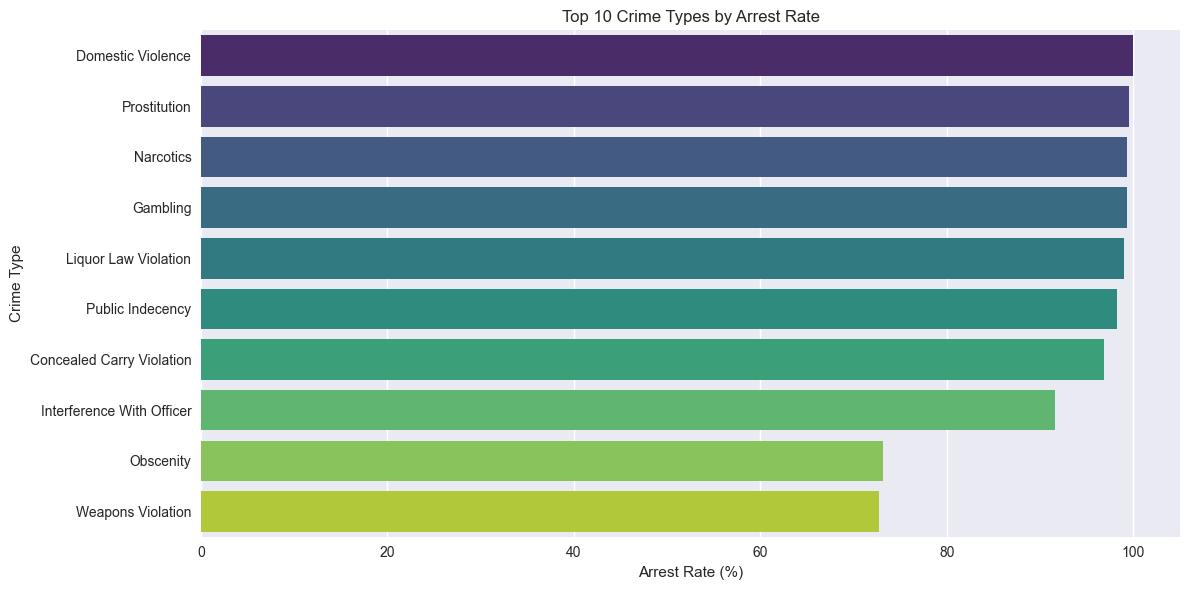

In [60]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Arrest_Rate', y='PrimaryType', data=ArrestRate.sort_values(by='Arrest_Rate', ascending=False).head(10), palette='viridis')
plt.title('Top 10 Crime Types by Arrest Rate')
plt.xlabel('Arrest Rate (%)')
plt.ylabel('Crime Type')
plt.tight_layout()
plt.savefig('arrest_rate.png', dpi=300, bbox_inches='tight')
plt.show()

Police actively patrol and pursue these crimes rather than responding to reports. If police are there making the arrest, the arrest rate is nearly 100%.

In [61]:
covid = CrimeByMonth[CrimeByMonth['Crime_Year'].between(2018, 2022)]

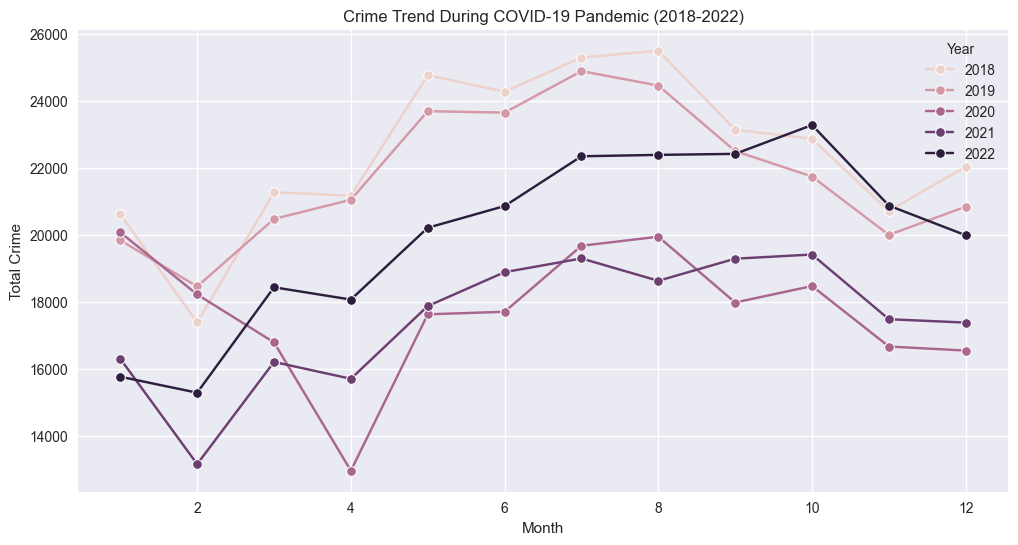

In [62]:
plt.figure(figsize = (12, 6))
sns.lineplot(x='Crime_Month', y='Total_Crime', hue='Crime_Year', data=covid, marker='o')
plt.title('Crime Trend During COVID-19 Pandemic (2018-2022)')
plt.xlabel('Month')
plt.ylabel('Total Crime')
plt.legend(title='Year')
plt.savefig('covid_impact.png', dpi=300, bbox_inches='tight')
plt.show()

Chicago crime dropped sharply in March 2020 when COVID-19 lockdowns began, hitting a low of ~13k crimes in April 2020 — nearly 50% below pre-pandemic levels. Crime gradually recovered through 2021-2022 but has not returned to pre-COVID levels.

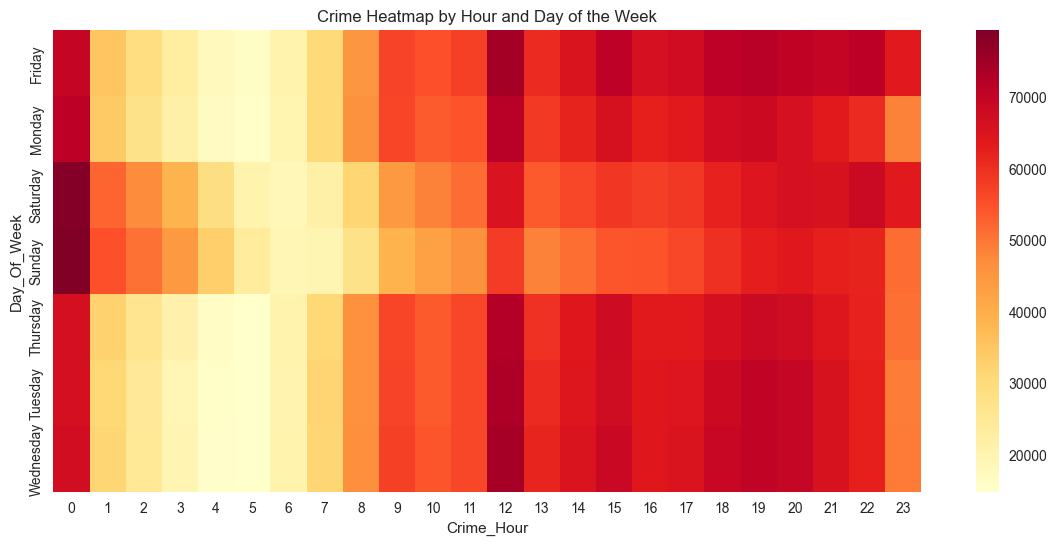

In [63]:
HeatMap = CrimeByHour.pivot(
    index = 'Day_Of_Week',
    columns = 'Crime_Hour',
    values = 'Total_Crime'
)

plt.figure(figsize = (14, 6))
sns.heatmap(HeatMap, cmap='YlOrRd', annot=False)
plt.title('Crime Heatmap by Hour and Day of the Week')
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

Crime peaks at midnight on weekends and drops to its lowest point between 4-7am across all days of the week.